In [1]:

import sys
from pathlib import Path
sys.path.insert(0, '/Volumes/SSD/GitHub/mtlearn/scripts/benchmarks')
import cfp_cache_p0 as diagnostic_reference
build, extension = diagnostic_reference.runtime('build/cfp-cache-p0-release')
import cv2
cv2.setNumThreads(0)
P5_OUTPUT = Path('/Volumes/SSD/GitHub/mtlearn/docs/cfp-cache/p5/runs/original_mps')
diagnostic_reference.write_json(P5_OUTPUT / "provenance.json", diagnostic_reference.provenance(build, extension))


Local dataset version of `CFP_linear_vs_mlp_scoring_screws_segmentation.ipynb`.
The dataset is read directly from disk; no download or file renaming is required.


# CFP linear vs MLP scoring — 205_SA_L3D14M3 segmentation

Compare the original notebook's linear sigmoid scorer and small MLP scorer using
`enhancement` as the input and `frag_component` as the supervised binary mask.
The max-tree, attribute set, optimizer, loss, and threshold-calibration procedure
are preserved. Each input is paired with its mask by numeric filename ID, so
`enhancement/0.png` matches `frag_component/0000.png`.

The inspected folder contains 2,048 inputs and 2,041 masks. IDs 2041–2047 have no
mask and are excluded with an explicit warning. The notebook rescans the folder
on each run, so these counts are informational rather than hard-coded limits.


## Local environment

Run this notebook in a Python environment with this repository's `mtlearn` and
notebook dependencies installed. If needed, run the following once from the
repository root, then restart/select that environment's Jupyter kernel:

```sh
python -m pip install ".[notebooks]"
```

The dataset path is configured below. The external SSD must be mounted. For a
first short run, set `MAX_SAMPLES = 3` and `NUM_EPOCHS = 1`; the experiment defaults
still select all matched pairs and 100 epochs. Configure `CACHE_DIR` and the
explicit SSD quota before running. The default 4 GiB quota is for small runs;
a one-image estimate stops a larger selection before a long preparation pass.
The full-resolution dataset was projected at about 477 GiB of raw morphology
before serialization and margins, so do not assume it fits the available SSD. Images are now loaded at their original resolution.
To reproduce the earlier reduced-resolution run, set both `NUM_ROWS` and
`NUM_COLS` to 256. The original
Colab installation cell is replaced because these data are local.


In [2]:
import sys
print("Python:", sys.executable)


Python: /opt/anaconda3/bin/python


## Setup

Import the libraries, fix the random seed, and select CUDA, MPS, or CPU.
The printed package path identifies the `mtlearn` installation used by the kernel.


In [3]:
from pathlib import Path
import hashlib
import json
import math
import random
import sys
import time
import warnings

import cv2
from IPython.display import display

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

import mtlearn
from mtlearn import morphology
from mtlearn.layers import ConnectedFilterPreprocessingLayer
from mtlearn.layers.cfp import CFPPreprocessor, DiskStore, PreparedDataset, collate_prepared

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
generator = torch.Generator(device="cpu").manual_seed(SEED)

device = 'mps'
print("device:", device)

print("mtlearn:", mtlearn.__file__)


device: mps
mtlearn: /Volumes/SSD/GitHub/mtlearn/mtlearn/python/mtlearn/__init__.py


## Experiment configuration

Both CFP layers use a max-tree and the same attributes. They differ only in the
scoring model: a linear sigmoid scorer or a nonlinear MLP scorer. The target is
the white foreground in `frag_component`, without the inversion used for screws.
Inputs also retain their original intensity polarity by default.

Set `NUM_ROWS = None` and `NUM_COLS = None` to preserve each image and mask's
original spatial dimensions (2,748 × 2,748 in this dataset). This is the default:
no interpolation is performed. Inputs are still normalized to `[0, 1]`, and masks
still become binary `float32` tensors. To resize, supply both positive dimensions,
for example `NUM_ROWS = 256` and `NUM_COLS = 256`. Resized inputs use area
interpolation and resized masks use nearest-neighbor interpolation.

In original-size mode, `BATCH_SIZE` defaults to 1 and `CACHE_IMAGES` defaults to
False. Caching all 2,041 full-resolution input/mask pairs alone would require
about 115 GiB, compared with about 1.0 GiB at 256 × 256. One shared SSD stores raw morphology for both models, with no RAM retention by
default. Evaluation keeps one batch and bounded threshold/pixel blocks, plus
small scalar summaries. Native preparation and the active batch still require
working memory; the cache/input budgets do not cap total RSS.
`MAX_SAMPLES` optionally selects a reproducible subset before the train/test
split. Batches larger than one require matching image sizes across samples.

The loss combines soft Dice and foreground-balanced BCE. Foreground weights,
attribute statistics, and response thresholds use only the training split.
`test_f1_fixed` retains threshold 0.5 as a reference.


In [4]:
DATASET_NAME = "205_SA_L3D14M3"
DATASET_ROOT = Path("/Volumes/SSD/GitHub/Dennis/dataset_patches/205_SA_L3D14M3")
INPUT_SUBDIR = "enhancement"
TARGET_SUBDIR = "frag_component"
INVERT_INPUT = False
MAX_SAMPLES = 3
TEST_SIZE = 0.3
# Set BOTH to None for original dimensions, or BOTH to positive sizes to resize.
NUM_ROWS = None
NUM_COLS = None
CACHE_IMAGES = NUM_ROWS is not None and NUM_COLS is not None
BATCH_SIZE = 1 if NUM_ROWS is None else 8
OUTPUT_SCALE = 255.0
RESPONSE_THRESHOLD = 0.5
THRESHOLD_GRID = [round(value, 2) for value in np.linspace(0.05, 0.95, 91)]

# Storage/process budgets are separate from the mathematical experiment.
CACHE_DIR = Path('/Volumes/SSD/GitHub/mtlearn/build/cfp-cache-p5-original')
CACHE_VERSION = "v1"  # Change after intentional edits to source pixels/order.
CACHE_MAX_DISK_BYTES = 1073741824
CACHE_MAX_RAM_BYTES = 0
PREPARATION_WORKERS = 1
PREPARATION_MAX_IN_FLIGHT = 1
PREPARATION_WORKER_THREADS = 1
PREPARATION_MAX_SAMPLE_BYTES = 64 * 1024**2
EVAL_THRESHOLD_BLOCK_SIZE = 8
EVAL_PIXEL_BLOCK_SIZE = 262144

TREE_TYPE = "max-tree"
TREE_ENUM = morphology.TreeType.MAX_TREE

# Same attribute set as the original comparison.
FILTER_ATTRIBUTES = (morphology.AttributeGroup.ALL,)

SCORE_SHARPNESS = 1.0
CLAMP_LOGIT = 12.0
IDENTITY_P0 = 0.995
LEARNING_RATE = 0.01
WEIGHT_DECAY = 1e-7
GRAD_CLIP = 5.0
NUM_EPOCHS = 1
REPORT_EPOCHS = {1}
DICE_LOSS_WEIGHT = 0.5
BCE_LOSS_WEIGHT = 0.5
MLP_HIDDEN_UNITS = [8]
MLP_ACTIVATION = "tanh"

config = {
    "task": "segmentation",
    "dataset": DATASET_NAME,
    "tree": TREE_TYPE,
    "input_size": "original" if NUM_ROWS is None and NUM_COLS is None else f"{NUM_ROWS}x{NUM_COLS}",
    "dataset_root": str(DATASET_ROOT),
    "input_source": INPUT_SUBDIR,
    "target_source": TARGET_SUBDIR,
    "pairing": "numeric filename ID",
    "invert_input": INVERT_INPUT,
    "target_foreground": "nonzero (white), without inversion",
    "max_samples": MAX_SAMPLES,
    "cache_images": CACHE_IMAGES,
    "cache_directory": str(CACHE_DIR.resolve()),
    "cache_max_disk_gib": CACHE_MAX_DISK_BYTES / 1024**3,
    "cache_max_ram_mib": CACHE_MAX_RAM_BYTES / 1024**2,
    "preparation_workers": PREPARATION_WORKERS,
    "preparation_max_in_flight": PREPARATION_MAX_IN_FLIGHT,
    "evaluation_threshold_block": EVAL_THRESHOLD_BLOCK_SIZE,
    "evaluation_pixel_block": EVAL_PIXEL_BLOCK_SIZE,
    "test_size": TEST_SIZE,
    "seed": SEED,
    "filter_attributes": [attribute.name for attribute in FILTER_ATTRIBUTES],
    "linear_scoring": {"kind": "linear_sigmoid"},
    "mlp_scoring": {"kind": "mlp", "hidden_units": MLP_HIDDEN_UNITS, "activation": MLP_ACTIVATION},
    "scale_mode": "dataset_clipped_zscore01",
    "score_sharpness": SCORE_SHARPNESS,
    "loss": "0.5 * soft_dice + 0.5 * foreground_balanced_bce",
    "threshold_selection": "best train F1 over [0.05, 0.95]",
    "fixed_response_threshold": RESPONSE_THRESHOLD,
    "learning_rate": LEARNING_RATE,
    "num_epochs": NUM_EPOCHS,
}
display(pd.DataFrame([config]))


,task,dataset,tree,input_size,dataset_root,input_source,target_source,pairing,invert_input,target_foreground,...,filter_attributes,linear_scoring,mlp_scoring,scale_mode,score_sharpness,loss,threshold_selection,fixed_response_threshold,learning_rate,num_epochs
0,segmentation,205_SA_L3D14M3,max-tree,original,/Volumes/SSD/GitHub/Dennis/dataset_patches/205...,enhancement,frag_component,numeric filename ID,False,"nonzero (white), without inversion",...,[ALL],{'kind': 'linear_sigmoid'},"{'kind': 'mlp', 'hidden_units': [8], 'activati...",dataset_clipped_zscore01,1.0,0.5 * soft_dice + 0.5 * foreground_balanced_bce,"best train F1 over [0.05, 0.95]",0.5,0.01,1


## Dataset and pair inspection

Only matching numeric IDs are used, in numeric order. The loader reports missing
partners and rejects duplicate numeric IDs (such as both `1.png` and `0001.png`
in the same folder). It verifies that each image/mask pair has matching original
spatial dimensions before any optional resizing, and that the PNGs are grayscale `uint8` with
binary mask values (0/255 or 0/1). Missing masks are never replaced by background.

The seeded 70/30 random split follows the original notebook's protocol. As all
samples belong to `205_SA_L3D14M3`, this measures a split within this dataset.
If IDs correspond to adjacent slices or related patches, their correlation can
make this split optimistic; it does not establish generalization to other volumes.


Inputs: 2048 | Masks: 2041 | Matched: 2041 | Selected: 3


/var/folders/33/bckvp5w94v58qwh5l_z21nn00000gn/T/ipykernel_53867/2430814028.py:104: UserWarning: Inputs without masks: [2041, 2042, 2043, 2044, 2045, 2046, 2047]. Excluding these IDs.
  dataset = EnhancementFragmentDataset(


,id,input,target
0,1000,1000.png,1000.png
1,1068,1068.png,1068.png
2,1316,1316.png,1316.png


trainset: 2
testset: 1


Loaded spatial dimensions (ID 1000): 2748 x 2748
Resizing: disabled
Image cache: disabled; estimated size for all selected pairs at these dimensions: 0.17 GiB
Reading training pairs and measuring foreground at the loaded resolution...


train foreground fraction: 0.009109
positive BCE weight: 108.782


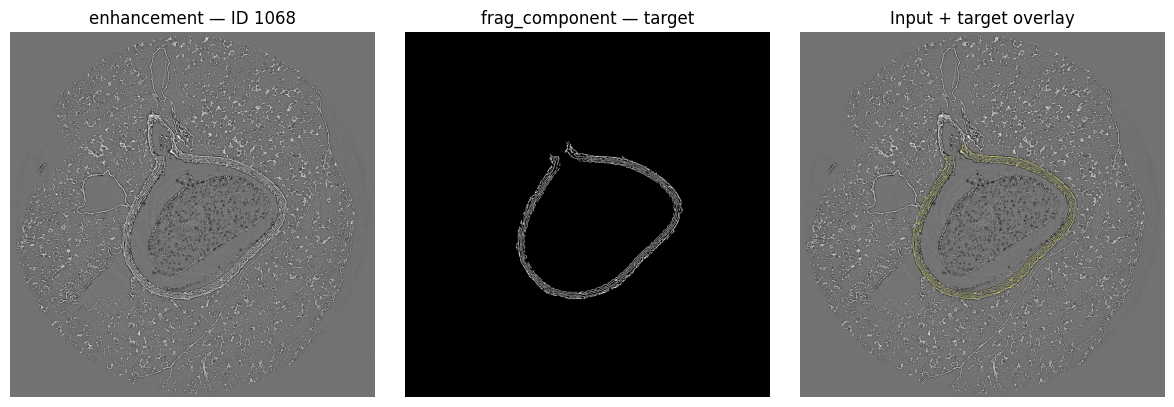

In [5]:
class EnhancementFragmentDataset(torch.utils.data.Dataset):
    """Pair two PNG folders by numeric ID and preserve the mask's foreground."""

    def __init__(self, root, rows=None, cols=None, *, invert_input=False,
                 cache_images=False, max_samples=None, seed=42):
        self.root = Path(root).expanduser()
        if (rows is None) != (cols is None):
            raise ValueError("NUM_ROWS and NUM_COLS must both be None or both be positive.")
        self.rows = None if rows is None else int(rows)
        self.cols = None if cols is None else int(cols)
        if self.rows is not None and (self.rows <= 0 or self.cols <= 0):
            raise ValueError("NUM_ROWS and NUM_COLS must be positive when resizing.")
        self.invert_input = bool(invert_input)
        self.cache_images = bool(cache_images)
        self._cache = {}

        inputs = self._index_folder(self.root / INPUT_SUBDIR)
        targets = self._index_folder(self.root / TARGET_SUBDIR)
        self.missing_target_ids = sorted(inputs.keys() - targets.keys())
        self.missing_input_ids = sorted(targets.keys() - inputs.keys())
        for label, missing in [("Inputs without masks", self.missing_target_ids),
                               ("Masks without inputs", self.missing_input_ids)]:
            if missing:
                warnings.warn(f"{label}: {missing}. Excluding these IDs.", stacklevel=2)

        paired_ids = sorted(inputs.keys() & targets.keys())
        self.available_pairs = len(paired_ids)
        if max_samples is not None:
            if isinstance(max_samples, bool) or not isinstance(max_samples, int) or max_samples < 2:
                raise ValueError("MAX_SAMPLES must be None or an integer >= 2.")
            if max_samples < len(paired_ids):
                selected = np.random.RandomState(seed).choice(
                    len(paired_ids), size=max_samples, replace=False,
                )
                paired_ids = [paired_ids[int(i)] for i in sorted(selected)]
        if len(paired_ids) < 2:
            raise ValueError(f"Need at least two matched pairs in {self.root}.")

        self.pairs = [(sample_id, inputs[sample_id], targets[sample_id])
                      for sample_id in paired_ids]
        self.manifest = pd.DataFrame([
            {"id": sample_id, "input": image_path.name, "target": mask_path.name}
            for sample_id, image_path, mask_path in self.pairs
        ])
        print(f"Inputs: {len(inputs)} | Masks: {len(targets)} | "
              f"Matched: {self.available_pairs} | Selected: {len(self)}")

    @staticmethod
    def _index_folder(folder):
        if not folder.is_dir():
            raise FileNotFoundError(f"Dataset folder not found: {folder}")
        indexed = {}
        for path in sorted(folder.iterdir()):
            if not path.is_file() or path.suffix.lower() != ".png":
                continue
            if not path.stem.isdecimal():
                raise ValueError(f"Expected a numeric PNG filename: {path}")
            sample_id = int(path.stem)
            if sample_id in indexed:
                raise ValueError(f"Duplicate numeric ID {sample_id}: "
                                 f"{indexed[sample_id]} and {path}")
            indexed[sample_id] = path
        return indexed

    @staticmethod
    def _read_grayscale(path):
        image = cv2.imread(str(path), cv2.IMREAD_UNCHANGED)
        if image is None:
            raise RuntimeError(f"Could not read PNG: {path}")
        if image.ndim != 2 or image.dtype != np.uint8:
            raise ValueError(f"Expected a grayscale uint8 PNG: {path}; "
                             f"got shape={image.shape}, dtype={image.dtype}")
        return image

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, index):
        index = int(index)
        if index in self._cache:
            return self._cache[index]
        sample_id, image_path, mask_path = self.pairs[index]
        image = self._read_grayscale(image_path)
        mask = self._read_grayscale(mask_path)
        if image.shape != mask.shape:
            raise ValueError(f"Shape mismatch for ID {sample_id}: "
                             f"input={image.shape}, mask={mask.shape}")
        values = set(np.unique(mask).tolist())
        if not (values <= {0, 255} or values <= {0, 1}):
            raise ValueError(f"Expected a binary mask for ID {sample_id}; got {values}")
        if self.invert_input:
            image = 255 - image
        if self.rows is not None:
            image = cv2.resize(image, (self.cols, self.rows), interpolation=cv2.INTER_AREA)
            mask = cv2.resize(mask, (self.cols, self.rows), interpolation=cv2.INTER_NEAREST)
        image_tensor = torch.from_numpy(image.astype(np.float32) / 255.0).unsqueeze(0)
        target_tensor = torch.from_numpy((mask > 0).astype(np.float32)).unsqueeze(0)
        sample = (image_tensor, target_tensor, str(sample_id))
        if self.cache_images:
            self._cache[index] = sample
        return sample


dataset = EnhancementFragmentDataset(
    DATASET_ROOT, NUM_ROWS, NUM_COLS,
    invert_input=INVERT_INPUT,
    cache_images=CACHE_IMAGES,
    max_samples=MAX_SAMPLES,
    seed=SEED,
)
display(dataset.manifest.head(10))

if not 0 < TEST_SIZE < 1:
    raise ValueError("TEST_SIZE must be between 0 and 1.")
num_test = int(np.ceil(len(dataset) * TEST_SIZE))
if num_test >= len(dataset):
    raise ValueError("TEST_SIZE leaves no training samples.")
permutation = np.random.RandomState(SEED).permutation(len(dataset))
test_indices = permutation[:num_test].tolist()
train_indices = permutation[num_test:].tolist()
trainset = torch.utils.data.Subset(dataset, train_indices)
testset = torch.utils.data.Subset(dataset, test_indices)

split_manifest = dataset.manifest.copy()
split_manifest["split"] = "train"
split_manifest.loc[test_indices, "split"] = "test"
print("trainset:", len(trainset))
print("testset:", len(testset))
sample_input, sample_target, sample_name = dataset[0]
loaded_rows, loaded_cols = sample_input.shape[-2:]
print(f"Loaded spatial dimensions (ID {sample_name}): {loaded_rows} x {loaded_cols}")
print("Resizing:", "disabled" if dataset.rows is None else "enabled")
print(f"Image cache: {'enabled' if CACHE_IMAGES else 'disabled'}; "
      f"estimated size for all selected pairs at these dimensions: "
      f"{len(dataset) * (sample_input.numel() * sample_input.element_size() + sample_target.numel() * sample_target.element_size()) / 1024**3:.2f} GiB")
del sample_input, sample_target

trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=False,
    num_workers=0, generator=generator,
)
testloader = torch.utils.data.DataLoader(
    testset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=False, num_workers=0,
)

positive_pixels = 0
total_pixels = 0
print("Reading training pairs and measuring foreground at the loaded resolution...")
for position, (_, target, _) in enumerate(trainset, start=1):
    positive_pixels += int((target >= 0.5).sum().item())
    total_pixels += int(target.numel())
    if position % 250 == 0:
        print(f"  {position}/{len(trainset)} training pairs")
if not 0 < positive_pixels < total_pixels:
    raise ValueError("Training masks must contain both foreground and background. "
                     "Check the dataset, subset size, and resize resolution.")
FOREGROUND_FRACTION = positive_pixels / total_pixels
POSITIVE_BCE_WEIGHT = (total_pixels - positive_pixels) / positive_pixels
print(f"train foreground fraction: {FOREGROUND_FRACTION:.6f}")
print(f"positive BCE weight: {POSITIVE_BCE_WEIGHT:.3f}")

image_in, image_target, name = trainset[0]
input_preview = image_in.squeeze().numpy()
target_preview = image_target.squeeze().numpy()
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(input_preview, cmap="gray", vmin=0, vmax=1)
axes[0].set_title(f"enhancement — ID {name}")
axes[1].imshow(target_preview, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("frag_component — target")
axes[2].imshow(input_preview, cmap="gray", vmin=0, vmax=1)
axes[2].imshow(np.ma.masked_where(target_preview == 0, target_preview),
               cmap="autumn", alpha=0.7, vmin=0, vmax=1)
axes[2].set_title("Input + target overlay")
for axis in axes:
    axis.axis("off")
plt.tight_layout()
plt.show()
plt.close(fig)
del image_in, image_target, input_preview, target_preview, fig, axes, axis


## CFP layers

Both CFP layers use the same morphology tree, attributes, normalization, `score_sharpness`, and initialization. Only the scoring model changes.

One versioned SSD preparation serves both scorers. Training statistics are fitted
once, frozen, and installed in both layers. Test preparation contributes no
statistics. Pixel identities are verified by MTLearn when reading the source.
`CACHE_VERSION` separates deliberate edits to source pixels/order; tree/features,
resolution and split also participate in the manifest identity. Repeating this
cell reuses completed entries. The preparation workers close before training.

The old cached loader used sequential order even though its input loader requested
shuffle; the new prepared loaders preserve that effective order. Two CPU seed
draws per model preserve the previous MLP identity initialization.


In [6]:
def make_filter_spec(name, scoring):
    return {
        "name": name,
        "tree_type": TREE_ENUM,
        "attributes": FILTER_ATTRIBUTES,
        "score_sharpness": SCORE_SHARPNESS,
        "scoring": scoring,
    }


def make_layer(spec_name, scoring):
    return ConnectedFilterPreprocessingLayer(
        in_channels=1,
        filter_specs=[make_filter_spec(spec_name, scoring)],
        scale_mode="dataset_clipped_zscore01",
        device=device,
        clamp=CLAMP_LOGIT,
    )


cfp_layers = {
    "Linear scoring": make_layer("linear_scoring", {"kind": "linear_sigmoid"}),
    "Nonlinear MLP scoring": make_layer(
        "nonlinear_mlp_scoring",
        {"kind": "mlp", "hidden_units": MLP_HIDDEN_UNITS, "activation": MLP_ACTIVATION},
    ),
}

class PairSource(torch.utils.data.Dataset):
    """Drop the display name; pass stable logical IDs separately to preparation."""
    def __init__(self, subset):
        self.subset = subset

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, index):
        image, target, _ = self.subset[index]
        return image, target


train_source, test_source = PairSource(trainset), PairSource(testset)
train_ids = [str(dataset.pairs[i][0]) for i in train_indices]
test_ids = [str(dataset.pairs[i][0]) for i in test_indices]
preprocessor = CFPPreprocessor.from_layer(cfp_layers["Linear scoring"])
source_contract = {
    "root": str(DATASET_ROOT.resolve()), "input": INPUT_SUBDIR, "target": TARGET_SUBDIR,
    "train_ids": train_ids, "test_ids": test_ids, "version": CACHE_VERSION,
}
source_version = hashlib.sha256(json.dumps(source_contract, sort_keys=True).encode()).hexdigest()
preprocessing_version = json.dumps({
    "rows": NUM_ROWS, "cols": NUM_COLS, "invert_input": INVERT_INPUT,
    "input": "float32-u8-div255-to-cfp-u8-v1", "mask": "nonzero-v1",
}, sort_keys=True)
manifest_contract = {
    "source": source_version, "preprocessing": preprocessing_version,
    "features": {key: [attr.name for attr in spec.attributes]
                 for key, spec in preprocessor.features.items()},
}
manifest_id = hashlib.sha256(json.dumps(manifest_contract, sort_keys=True).encode()).hexdigest()
manifest_names = {split: f"{split}-{manifest_id}" for split in ("train", "test")}

# Close a previous reader when rerunning this cell in an interactive kernel.
if globals().get("cache_store") is not None:
    cache_store.close()

with DiskStore(CACHE_DIR, max_disk_bytes=CACHE_MAX_DISK_BYTES, max_ram_bytes=0) as writer:
    # One pilot, subsequently reused, estimates capacity before a long pass.
    pilot_image, pilot_target = train_source[0]
    pilot = preprocessor.prepare_batch(pilot_image[None], store=writer, sample_ids=train_ids[:1])
    pilot_raw_bytes = sum(prepared.nbytes for channel in pilot.samples[0] for prepared in channel.values())
    estimated_disk_bytes = math.ceil(pilot_raw_bytes * len(dataset) * 1.15)
    del pilot, pilot_image, pilot_target
    print(f"SSD estimate from one image (+15% margin): {estimated_disk_bytes / 1024**3:.2f} GiB; "
          f"configured quota: {CACHE_MAX_DISK_BYTES / 1024**3:.2f} GiB")
    if estimated_disk_bytes > CACHE_MAX_DISK_BYTES:
        raise RuntimeError("Selected dataset exceeds the configured SSD estimate. Set MAX_SAMPLES for a short run, "
                           "or choose a larger measured CACHE_MAX_DISK_BYTES budget and rerun. "
                           "The pilot remains reusable; do not assume the full dataset fits the SSD.")
    preparation_options = {
        "store": writer, "source_version": source_version,
        "preprocessing_version": preprocessing_version, "num_workers": PREPARATION_WORKERS,
        "max_in_flight": PREPARATION_MAX_IN_FLIGHT if PREPARATION_WORKERS else None,
        "worker_threads": PREPARATION_WORKER_THREADS,
        "max_sample_bytes": PREPARATION_MAX_SAMPLE_BYTES,
    }
    print("Preparing shared training morphology and statistics...")
    train_preparation = preprocessor.prepare(
        train_source, manifest=manifest_names["train"], split="train", sample_ids=train_ids,
        collect_stats=cfp_layers["Linear scoring"].get_statistics_contract(), **preparation_options,
    )
    print("Preparing test morphology with frozen training statistics...")
    test_preparation = preprocessor.prepare(
        test_source, manifest=manifest_names["test"], split="evaluation", sample_ids=test_ids,
        **preparation_options,
    )
    preparation_info = writer.info()

cache_store = DiskStore(CACHE_DIR, readonly=True, max_ram_bytes=CACHE_MAX_RAM_BYTES)
prepared_datasets = {
    "train": PreparedDataset(cache_store, manifest_names["train"], source=train_source),
    "test": PreparedDataset(cache_store, manifest_names["test"], source=test_source),
}
# The old cache builder disabled shuffle. Preserve that effective training order.
prepared_loaders = {
    split: torch.utils.data.DataLoader(source, batch_size=BATCH_SIZE, shuffle=False,
                                      num_workers=0, pin_memory=False, collate_fn=collate_prepared)
    for split, source in prepared_datasets.items()
}
layer_rows = []
for model_name, layer in cfp_layers.items():
    layer.set_stats(train_preparation.statistics)
    # The two legacy cache passes each drew a CPU DataLoader base seed before
    # init_identity. Preserve those draws so the MLP's random output weights
    # match the previous notebook, without re-reading or caching any images.
    for _ in range(2):
        torch.empty((), dtype=torch.int64).random_()
    layer.init_identity(p0=IDENTITY_P0)
    spec_config = layer.get_config()["filter_specs"][0]
    layer_rows.append({
        "model": model_name, "filter_name": spec_config["name"], "scoring": spec_config["scoring"],
        "parameter_contract": layer.get_parameter_contract(),
    })
    assert layer.cached_sample_count() == 0
print(f"Shared SSD: {preparation_info['disk_entries']} entries, "
      f"{preparation_info['disk_bytes'] / 1024**3:.3f} GiB; RAM retention budget: "
      f"{CACHE_MAX_RAM_BYTES / 1024**2:.1f} MiB")
display(pd.DataFrame(layer_rows))


SSD estimate from one image (+15% margin): 0.79 GiB; configured quota: 1.00 GiB
Preparing shared training morphology and statistics...


Preparing test morphology with frozen training statistics...


Shared SSD: 3 entries, 0.689 GiB; RAM retention budget: 0.0 MiB


,model,filter_name,scoring,parameter_contract
0,Linear scoring,linear_scoring,{'kind': 'linear_sigmoid'},"{'weights': {'linear_scoring': [63]}, 'biases'..."
1,Nonlinear MLP scoring,nonlinear_mlp_scoring,"{'kind': 'mlp', 'hidden_units': [8], 'activati...","{'weights': {}, 'biases': {}, 'scoring_models'..."


In [7]:

# Diagnostic assertions only; this cell is absent from the canonical notebook.
from mtlearn.layers.cfp.normalization import AttributeNormalizer
p5_forbidden_calls = {"morphology": 0, "stats_update": 0, "stats_merge": 0, "stats_summary": 0}
def p5_forbid(name):
    def forbidden(*args, **kwargs):
        p5_forbidden_calls[name] += 1
        raise AssertionError(f"Unexpected {name} during training/evaluation")
    return forbidden
CFPPreprocessor.prepare_u8 = p5_forbid("morphology")
AttributeNormalizer.update = p5_forbid("stats_update")
AttributeNormalizer.merge = p5_forbid("stats_merge")
AttributeNormalizer.summarize = p5_forbid("stats_summary")
def p5_parameter_hash(layer):
    digest = hashlib.sha256()
    for name, parameter in layer.named_parameters():
        digest.update(name.encode())
        digest.update(parameter.detach().cpu().contiguous().numpy().tobytes())
    return digest.hexdigest()
p5_initial_hashes = {name: p5_parameter_hash(layer) for name, layer in cfp_layers.items()}
p5_gradient_norms = []
p5_clip = torch.nn.utils.clip_grad_norm_
def p5_check_gradients(parameters, *args, **kwargs):
    parameters = list(parameters)
    gradients = [parameter.grad for parameter in parameters if parameter.grad is not None]
    assert gradients and all(torch.isfinite(gradient).all() for gradient in gradients)
    norm = p5_clip(parameters, *args, **kwargs)
    p5_gradient_norms.append(float(norm.detach().cpu()))
    return norm
torch.nn.utils.clip_grad_norm_ = p5_check_gradients


## Evaluation utilities

The CFP layer returns an image-like response, not a calibrated probability map. We normalize each response image to `[0, 1]`, optimize the training loss on that response, and select the segmentation threshold on the training split. Test F1 is then computed with the train-selected threshold.

Evaluation never concatenates the dataset's responses or masks. Int64 confusion
counts are accumulated in blocks; `>=`, grid order, and first-on-tie selection
are unchanged. Dice is averaged per image; BCE is weighted by pixel count across
batches. The same weighting is used for the reported epoch loss, including a
short last batch; optimizer updates retain the original per-batch loss. Only one
test example is retained while drawing each comparison, and figures are closed.


In [8]:
def normalize_per_image(batch):
    dims = tuple(range(2, batch.ndim))
    low = batch.amin(dim=dims, keepdim=True)
    high = batch.amax(dim=dims, keepdim=True)
    return (batch - low) / torch.clamp(high - low, min=1e-6)


def soft_dice_loss(probabilities, targets, eps=1e-6):
    targets = targets.to(device=probabilities.device, dtype=probabilities.dtype)
    probs = probabilities.reshape(probabilities.size(0), -1)
    masks = targets.reshape(targets.size(0), -1)
    intersection = torch.sum(probs * masks, dim=1)
    denominator = torch.sum(probs, dim=1) + torch.sum(masks, dim=1)
    return (1.0 - (2.0 * intersection + eps) / (denominator + eps)).mean()


def balanced_bce_loss(probabilities, targets):
    targets = targets.to(device=probabilities.device, dtype=probabilities.dtype)
    probabilities = probabilities.clamp(1e-4, 1.0 - 1e-4)
    pixel_loss = F.binary_cross_entropy(probabilities, targets, reduction="none")
    positive_weight = torch.as_tensor(
        POSITIVE_BCE_WEIGHT,
        device=probabilities.device,
        dtype=probabilities.dtype,
    )
    pixel_weight = torch.where(targets >= 0.5, positive_weight, torch.ones_like(targets))
    return torch.mean(pixel_loss * pixel_weight)


def segmentation_loss(probabilities, targets):
    return (
        DICE_LOSS_WEIGHT * soft_dice_loss(probabilities, targets)
        + BCE_LOSS_WEIGHT * balanced_bce_loss(probabilities, targets)
    )


class SegmentationAccumulator:
    """Keep scalar losses and int64 counts; comparisons use bounded CPU blocks."""

    def __init__(self, thresholds, *, threshold_block_size=8, pixel_block_size=262144):
        self.thresholds = tuple(float(value) for value in thresholds)
        if not self.thresholds or not all(math.isfinite(value) for value in self.thresholds):
            raise ValueError("At least one finite threshold is required.")
        for value in (threshold_block_size, pixel_block_size):
            if type(value) is not int or value <= 0:
                raise ValueError("Evaluation block sizes must be positive integers.")
        self.threshold_block_size = threshold_block_size
        self.pixel_block_size = pixel_block_size
        self.counts = torch.zeros((len(self.thresholds), 4), dtype=torch.int64)
        self.dice_sum = self.bce_sum = 0.0
        self.image_count = self.pixel_count = 0

    @torch.no_grad()
    def update(self, responses, targets):
        # Like the old concatenation path, reporting is calculated on CPU.
        responses = responses.detach().cpu()
        targets = targets.detach().to(device="cpu", dtype=responses.dtype)
        if responses.ndim != 4 or responses.shape != targets.shape or responses.numel() == 0:
            raise ValueError("Expected nonempty BCHW responses and targets with matching shapes.")
        if not torch.isfinite(responses).all() or not torch.isfinite(targets).all():
            raise ValueError("Metrics require finite responses and targets.")
        image_count, pixel_count = responses.shape[0], responses.numel()
        self.dice_sum += soft_dice_loss(responses, targets).item() * image_count
        self.bce_sum += balanced_bce_loss(responses, targets).item() * pixel_count
        self.image_count += image_count
        self.pixel_count += pixel_count
        pixels = responses.reshape(-1)
        target = (targets >= 0.5).reshape(-1)
        # Convert thresholds to the response dtype, matching tensor >= scalar.
        thresholds = torch.tensor(self.thresholds, dtype=responses.dtype)
        for begin in range(0, pixel_count, self.pixel_block_size):
            stop = min(begin + self.pixel_block_size, pixel_count)
            truth = target[begin:stop]
            positive = truth.sum(dtype=torch.int64)
            for offset in range(0, len(thresholds), self.threshold_block_size):
                limits = thresholds[offset:offset + self.threshold_block_size]
                prediction = pixels[begin:stop][None, :] >= limits[:, None]
                tp = (prediction & truth[None, :]).sum(dim=1, dtype=torch.int64)
                predicted = prediction.sum(dim=1, dtype=torch.int64)
                fp, fn = predicted - tp, positive - tp
                tn = (stop - begin) - tp - fp - fn
                self.counts[offset:offset + len(limits)] += torch.stack((tp, fp, fn, tn), dim=1)

    @property
    def loss(self):
        if not self.image_count or not self.pixel_count:
            raise ValueError("Cannot report an empty evaluation.")
        return (DICE_LOSS_WEIGHT * self.dice_sum / self.image_count
                + BCE_LOSS_WEIGHT * self.bce_sum / self.pixel_count)

    def metrics(self, index):
        if not self.image_count:
            raise ValueError("Cannot report an empty evaluation.")
        tp, fp, fn, tn = self.counts[index].tolist()
        eps = 1e-12
        precision = tp / (tp + fp + eps)
        recall = tp / (tp + fn + eps)
        return {
            "threshold": self.thresholds[index], "iou": tp / (tp + fp + fn + eps),
            "f1": 2.0 * precision * recall / (precision + recall + eps),
            "precision": precision, "recall": recall,
            "accuracy": (tp + tn) / (tp + fp + fn + tn + eps),
            "foreground_fraction": (tp + fn) / (tp + fp + fn + tn + eps),
        }

    def best_f1(self, candidate_count=None):
        count = len(self.thresholds) if candidate_count is None else candidate_count
        if not 0 < count <= len(self.thresholds):
            raise ValueError("Invalid threshold candidate count.")
        # Python max preserves the FIRST grid entry on a tie, as before.
        return max((self.metrics(index) for index in range(count)), key=lambda row: row["f1"])


def evaluate_streaming(layer, dataloader, thresholds):
    accumulator = SegmentationAccumulator(
        thresholds, threshold_block_size=EVAL_THRESHOLD_BLOCK_SIZE, pixel_block_size=EVAL_PIXEL_BLOCK_SIZE,
    )
    was_training = layer.training
    layer.eval()
    try:
        with torch.no_grad():
            for batch_inputs, batch_targets in dataloader:
                response = normalize_per_image(layer(batch_inputs) / OUTPUT_SCALE)
                accumulator.update(response, batch_targets)
                del response, batch_inputs, batch_targets
    finally:
        layer.train(was_training)
    if not accumulator.image_count:
        raise ValueError("Cannot evaluate an empty loader.")
    return accumulator


def parameter_summary(layer):
    with torch.no_grad():
        total_sq = torch.zeros((), device=device)
        total_params = 0
        for parameter in layer.parameters():
            total_sq = total_sq + torch.sum(parameter.detach().to(device=device).float().square())
            total_params += parameter.numel()
        summary = {
            "num_parameters": int(total_params),
            "parameter_l2": float(torch.sqrt(total_sq).detach().cpu()),
        }
        if len(layer._weights) == 1:
            key = next(iter(layer._weights.keys()))
            summary["linear_weight_l2"] = float(torch.linalg.vector_norm(layer._weights[key].detach()).cpu())
            summary["linear_bias"] = float(layer._biases[key].detach().cpu().view(-1)[0])
        return summary


selected_thresholds = {}


def collect_metrics(epoch, model_name, layer, train_loss=None):
    train = evaluate_streaming(layer, prepared_loaders["train"], [*THRESHOLD_GRID, RESPONSE_THRESHOLD])
    train_metrics = train.best_f1(candidate_count=len(THRESHOLD_GRID))
    selected_threshold = train_metrics["threshold"]
    selected_thresholds[model_name] = selected_threshold
    # Test data never participates in selecting the threshold.
    test = evaluate_streaming(layer, prepared_loaders["test"], [selected_threshold, RESPONSE_THRESHOLD])
    test_metrics = test.metrics(0)
    row = {
        "epoch": int(epoch), "model": model_name, "learning_rate": LEARNING_RATE,
        "threshold": selected_threshold, "train_loss": train.loss, "test_loss": test.loss,
        "train_f1_fixed": train.metrics(len(THRESHOLD_GRID))["f1"],
        "test_f1_fixed": test.metrics(1)["f1"],
    }
    if train_loss is not None:
        row["train_epoch_loss"] = float(train_loss)
    row.update(parameter_summary(layer))
    row.update({f"train_{key}": value for key, value in train_metrics.items()})
    row.update({f"test_{key}": value for key, value in test_metrics.items()})
    return row


def show_segmentation_comparison(epoch):
    # One shared prepared image for both models, regardless of training batch size.
    model_items = list(cfp_layers.items())
    model_inputs, viz_targets = collate_prepared([prepared_datasets["test"][0]])
    viz_image, _, _ = testset[0]
    ncols = 2 + 2 * len(model_items)
    fig, axes = plt.subplots(1, ncols, figsize=(4 * ncols, 4))
    try:
        axes[0].imshow(viz_image[0].numpy(), cmap="gray", vmin=0, vmax=1)
        axes[0].set_title("Input")
        axes[1].imshow(viz_targets[0, 0].numpy(), cmap="gray", vmin=0, vmax=1)
        axes[1].set_title("Target mask")
        col = 2
        for model_name, layer in model_items:
            threshold = selected_thresholds.get(model_name, RESPONSE_THRESHOLD)
            was_training = layer.training
            layer.eval()
            try:
                with torch.no_grad():
                    response = normalize_per_image(layer(model_inputs) / OUTPUT_SCALE)
                    prediction = response >= threshold
                axes[col].imshow(response[0, 0].cpu().numpy(), cmap="gray", vmin=0, vmax=1)
                axes[col].set_title(f"{model_name}\nresponse")
                axes[col + 1].imshow(prediction[0, 0].cpu().numpy(), cmap="gray", vmin=0, vmax=1)
                axes[col + 1].set_title(f"{model_name}\nprediction t={threshold:.2f}")
                del response, prediction
            finally:
                layer.train(was_training)
            col += 2
        for axis in axes:
            axis.axis("off")
        fig.suptitle(f"Epoch {epoch}")
        plt.tight_layout()
        plt.show()
    finally:
        plt.close(fig)


## Initial state

Both CFP layers are initialized close to the identity. The table reports train/test segmentation metrics before any optimizer update.


,epoch,model,learning_rate,threshold,train_loss,test_loss,train_f1_fixed,test_f1_fixed,num_parameters,parameter_l2,...,train_recall,train_accuracy,train_foreground_fraction,test_threshold,test_iou,test_f1,test_precision,test_recall,test_accuracy,test_foreground_fraction
0,0,Linear scoring,0.01,0.82,0.899281,0.895088,0.140409,0.139212,64,5.293305,...,0.583661,0.976999,0.009109,0.82,0.19206,0.322232,0.222161,0.586348,0.978247,0.008819
1,0,Nonlinear MLP scoring,0.01,0.82,0.899283,0.895087,0.140409,0.139212,521,5.544222,...,0.583661,0.976999,0.009109,0.82,0.19206,0.322232,0.222161,0.586348,0.978247,0.008819


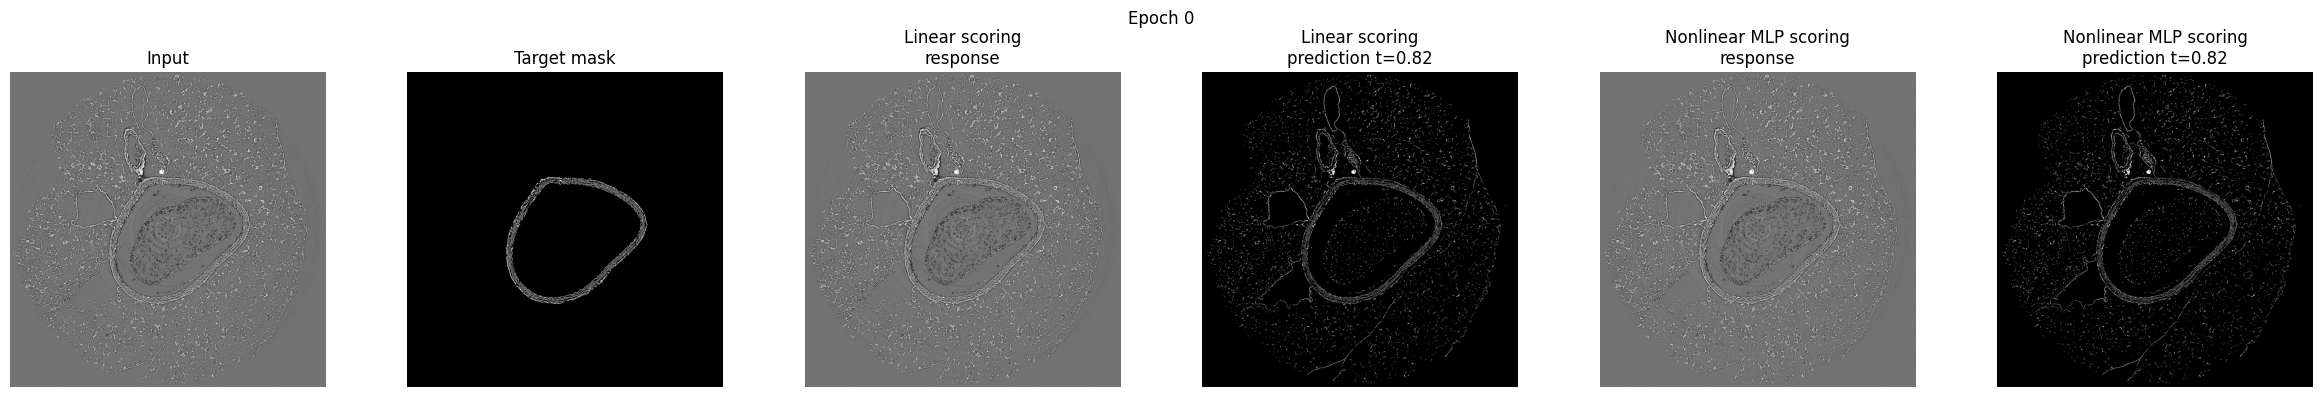

In [9]:
initial_rows = [
    collect_metrics(0, model_name, layer)
    for model_name, layer in cfp_layers.items()
]
initial_table = pd.DataFrame(initial_rows)
display(initial_table)
show_segmentation_comparison(epoch=0)


## Training

Each model is trained with the same optimizer and the same loss. The training loss is differentiable, while F1 is reported after threshold calibration on the train split.


,epoch,model,train_epoch_loss,threshold,train_f1_fixed,test_f1_fixed,train_f1,test_f1,train_iou,test_iou
0,1,Linear scoring,0.896843,0.82,0.140409,0.139212,0.31614,0.322232,0.187747,0.19206
1,1,Nonlinear MLP scoring,0.899280,0.82,0.140409,0.139212,0.31614,0.322232,0.187747,0.19206


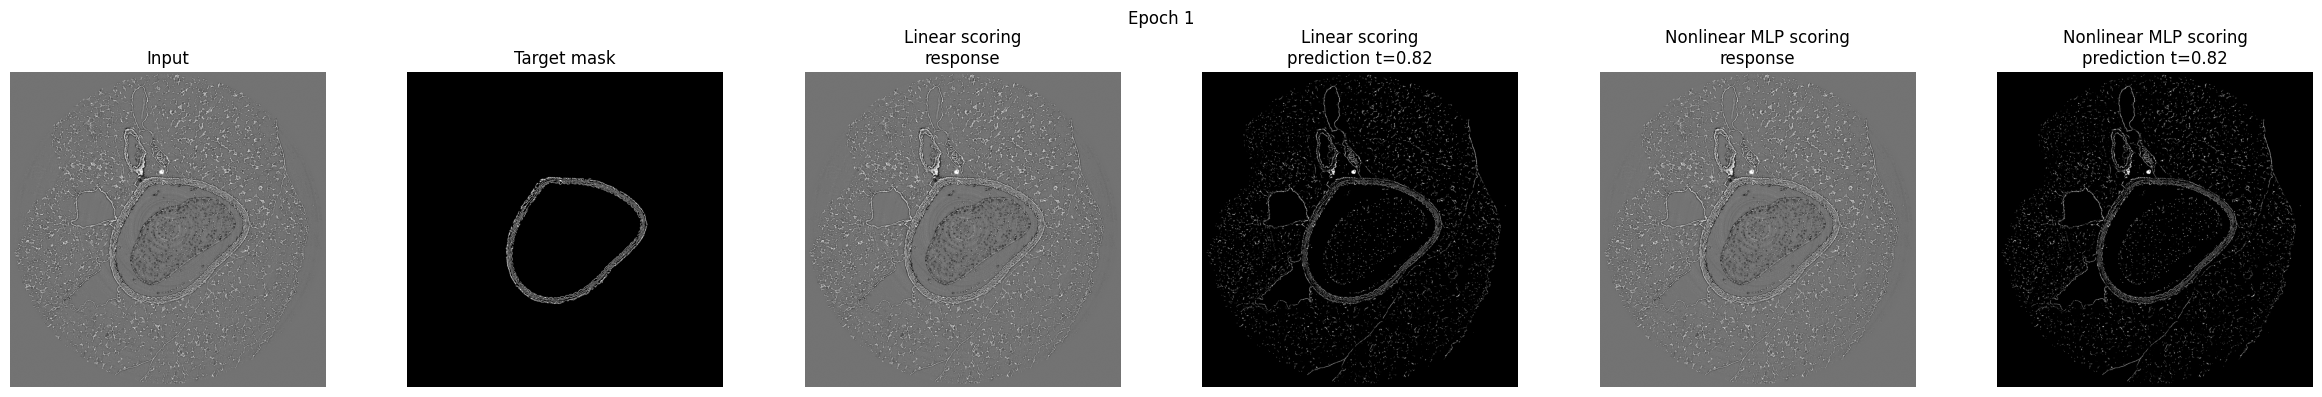

Training completed in 0.212 minutes.


In [10]:
optimizers = {
    model_name: torch.optim.Adam(layer.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    for model_name, layer in cfp_layers.items()
}
report_rows = list(initial_rows)
start = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_losses = {}

    for model_name, layer in cfp_layers.items():
        layer.train()
        epoch_dice_sum = epoch_bce_sum = 0.0
        epoch_images = epoch_pixels = 0
        train_prepared = prepared_loaders["train"]

        for batch_inputs, targets in train_prepared:
            response = normalize_per_image(layer(batch_inputs) / OUTPUT_SCALE)
            targets_on_device = targets.to(device=response.device, dtype=response.dtype)
            dice_loss = soft_dice_loss(response, targets_on_device)
            bce_loss = balanced_bce_loss(response, targets_on_device)
            loss = DICE_LOSS_WEIGHT * dice_loss + BCE_LOSS_WEIGHT * bce_loss

            optimizers[model_name].zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(layer.parameters(), max_norm=GRAD_CLIP)
            optimizers[model_name].step()

            epoch_dice_sum += dice_loss.item() * response.shape[0]
            epoch_bce_sum += bce_loss.item() * response.numel()
            epoch_images += response.shape[0]
            epoch_pixels += response.numel()
            # Release active CPU/GPU tensors before loading the next image.
            optimizers[model_name].zero_grad(set_to_none=True)
            del response, loss, dice_loss, bce_loss, targets_on_device, targets, batch_inputs

        epoch_losses[model_name] = (DICE_LOSS_WEIGHT * epoch_dice_sum / epoch_images
                                   + BCE_LOSS_WEIGHT * epoch_bce_sum / epoch_pixels)

    if epoch in REPORT_EPOCHS:
        epoch_rows = [
            collect_metrics(epoch, model_name, layer, train_loss=epoch_losses[model_name])
            for model_name, layer in cfp_layers.items()
        ]
        report_rows.extend(epoch_rows)
        display(
            pd.DataFrame(epoch_rows)[
                [
                    "epoch",
                    "model",
                    "train_epoch_loss",
                    "threshold",
                    "train_f1_fixed",
                    "test_f1_fixed",
                    "train_f1",
                    "test_f1",
                    "train_iou",
                    "test_iou",
                ]
            ]
        )
        show_segmentation_comparison(epoch=epoch)

elapsed_minutes = (time.time() - start) / 60.0
trajectory = pd.DataFrame(report_rows)
print(f"Training completed in {elapsed_minutes:.3f} minutes.")


## Results

The table and plots compare task fit and parameter growth for the linear and nonlinear scoring models.


,epoch,model,train_epoch_loss,train_loss,test_loss,threshold,train_f1_fixed,test_f1_fixed,train_iou,test_iou,train_f1,test_f1,parameter_l2,num_parameters
0,0,Linear scoring,NaN,0.899281,0.895088,0.82,0.140409,0.139212,0.187747,0.19206,0.31614,0.322232,5.293305,64
1,0,Nonlinear MLP scoring,NaN,0.899283,0.895087,0.82,0.140409,0.139212,0.187747,0.19206,0.31614,0.322232,5.544222,521
2,1,Linear scoring,0.896843,0.891328,0.887318,0.82,0.140409,0.139212,0.187747,0.19206,0.31614,0.322232,5.297223,64
3,1,Nonlinear MLP scoring,0.899280,0.899257,0.895062,0.82,0.140409,0.139212,0.187747,0.19206,0.31614,0.322232,5.560264,521


Final report


,epoch,model,train_epoch_loss,train_loss,test_loss,threshold,train_f1_fixed,test_f1_fixed,train_iou,test_iou,train_f1,test_f1,parameter_l2,num_parameters
2,1,Linear scoring,0.896843,0.891328,0.887318,0.82,0.140409,0.139212,0.187747,0.19206,0.31614,0.322232,5.297223,64
3,1,Nonlinear MLP scoring,0.899280,0.899257,0.895062,0.82,0.140409,0.139212,0.187747,0.19206,0.31614,0.322232,5.560264,521


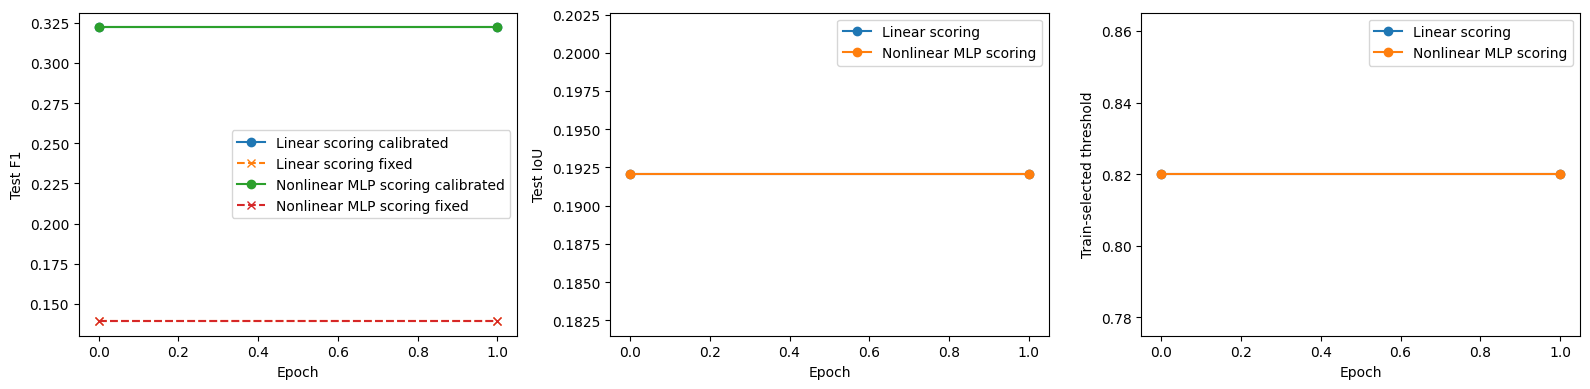

In [11]:
display_columns = [
    "epoch",
    "model",
    "train_epoch_loss",
    "train_loss",
    "test_loss",
    "threshold",
    "train_f1_fixed",
    "test_f1_fixed",
    "train_iou",
    "test_iou",
    "train_f1",
    "test_f1",
    "parameter_l2",
    "num_parameters",
]
display(trajectory[display_columns])

final_rows = trajectory.sort_values("epoch").groupby("model", as_index=False).tail(1)
print("Final report")
display(final_rows[display_columns])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for model_name, group in trajectory.groupby("model"):
    axes[0].plot(group["epoch"], group["test_f1"], marker="o", label=f"{model_name} calibrated")
    axes[0].plot(group["epoch"], group["test_f1_fixed"], linestyle="--", marker="x", label=f"{model_name} fixed")
    axes[1].plot(group["epoch"], group["test_iou"], marker="o", label=model_name)
    axes[2].plot(group["epoch"], group["threshold"], marker="o", label=model_name)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Test F1")
axes[0].legend()
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Test IoU")
axes[1].legend()
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Train-selected threshold")
axes[2].legend()
plt.tight_layout()
plt.show()
plt.close(fig)


## Design note

This experiment compares scoring models on the binary `frag_component` masks for
`205_SA_L3D14M3`. The two CFP layers differ only in their scoring map from normalized
node attributes to scores. The linear scorer uses an affine gate over attributes;
the MLP scorer provides a nonlinear mapping.

The loss combines soft Dice and foreground-balanced BCE because the mask
foreground is sparse. Attribute normalization, the positive BCE weight, and the
F1/IoU response threshold are fitted on the training split. Both scorers share raw SSD entries and frozen training statistics. Train/test
manifest identities remain distinct; test data never fits the statistics. Fixed-threshold F1 remains
in the table as a reference. Trees are built on CPU; only active CFP tensors and scorer
parameters use the selected `device`. Evaluation aggregates CPU counts/losses
without retaining a dataset of response tensors.

The defaults preserve the source notebook's 100 epochs, max-tree, and random
train/test protocol, while loading images at their original dimensions. Setting
both size parameters to 256 restores the earlier 256 × 256 experiment resolution.
When resizing is enabled, nearest-neighbor interpolation keeps masks binary but
can remove thin structures. Inspect the overlay at the chosen resolution before
interpreting metrics. Test curves are descriptive; the reported final row uses
the last configured epoch, rather than selecting an epoch by test performance.
A volume-level or spatially separated evaluation requires an additional split
protocol and, for generalization across volumes, additional datasets.


## Release the cache reader

Close the read-only handle after the tables and plots are complete. Prepared
files remain on SSD for resumption. Rerun the CFP preparation cell to reopen the
loaders before additional interactive training or evaluation.

In [12]:

import json
assert not any(p5_forbidden_calls.values()), p5_forbidden_calls
assert train_preparation.statistics.sample_count == len(trainset)
assert len(trainset) + len(testset) == MAX_SAMPLES
assert len(p5_gradient_norms) == 2 * len(prepared_loaders["train"])
assert all(math.isfinite(value) and value > 0 for value in p5_gradient_norms)
assert NUM_ROWS is None and NUM_COLS is None and BATCH_SIZE == 1
assert all(layer.cached_sample_count() == 0 for layer in cfp_layers.values())
for model_name, layer in cfp_layers.items():
    assert p5_initial_hashes[model_name] != p5_parameter_hash(layer)
    for key, fields in train_preparation.statistics.statistics.items():
        for name, value in fields.items():
            torch.testing.assert_close(layer.get_extra_state()["ds_stats"][key][name].cpu(), value)
    assert int((trajectory["model"] == model_name).sum()) == 2
cache = cache_store.info()
assert cache["retained_bytes"] == 0 and cache["active_bytes"] == 0, cache
assert cache["writes"] == 0
assert not plt.get_fignums()
trajectory.to_csv(P5_OUTPUT / "trajectory.csv", index=False)
split_manifest.to_csv(P5_OUTPUT / "split.csv", index=False)
summary = {
    "device": device, "sample_count": len(dataset), "train_ids": train_ids, "test_ids": test_ids,
    "loaded_size": [loaded_rows, loaded_cols], "epochs_per_model": NUM_EPOCHS,
    "gradient_norms_before_clip": p5_gradient_norms, "forbidden_calls": p5_forbidden_calls,
    "foreground_fraction": FOREGROUND_FRACTION, "positive_bce_weight": POSITIVE_BCE_WEIGHT,
    "preparation": preparation_info, "reader": cache, "selected_thresholds": selected_thresholds,
    "statistics_id": train_preparation.statistics_id, "manifest_names": manifest_names,
    "initial_parameter_sha256": p5_initial_hashes,
    "final_parameter_sha256": {name: p5_parameter_hash(layer) for name, layer in cfp_layers.items()},
    "config": config, "trajectory": trajectory.where(trajectory.notna(), None).to_dict(orient="records"),
    "note": "Integration test with three original-size images and one epoch per scorer; not a model-quality conclusion."
}
# Missing train_epoch_loss at epoch 0 is represented as null in JSON.
for row in summary["trajectory"]:
    for key, value in row.items():
        if isinstance(value, float) and math.isnan(value): row[key] = None
diagnostic_reference.write_json(P5_OUTPUT / "result.json", summary)
print("P5_NOTEBOOK_PASS")


P5_NOTEBOOK_PASS


In [13]:
print("Final cache state:", cache_store.info())
cache_store.close()

Final cache state: {'max_bytes': 0, 'retained_bytes': 0, 'entries': 0, 'hits': 18, 'misses': 0, 'evictions': 0, 'oversized_entries': 18, 'active_entries': 0, 'active_bytes': 0, 'active_not_retained_bytes': 0, 'live_bytes': 0, 'ram_hits': 0, 'disk_hits': 18, 'writes': 0, 'invalid_entries': 0, 'disk_entries': 3, 'entry_states': {'valid': 3}, 'disk_bytes': 739351347, 'manifest_bytes': 106496, 'max_disk_bytes': None, 'readonly': True}
